In [ ]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv('spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.value_counts()

Category  Message                                                                                                                                                                                                                                                                                                                                             isSpam
ham       Sorry, I'll call later                                                                                                                                                                                                                                                                                                                              0         30
          I cant pick the phone right now. Pls send a message                                                                                                                                                                                                                                                                                                 0         12
          Ok...                                                                                                                                                                                                                                                                                                                                               0         10
          Ok.                                                                                                                                                                                                                                                                                                                                                 0          4
          Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it...                                                                                                                                                                                 0          4
                                                                                                                                                                                                                                                                                                                                                                        ..
          I was about to do it when i texted. I finished a long time ago and showered and er'ything!                                                                                                                                                                                                                                                          0          1
          I wanted to wish you a Happy New Year and I wanted to talk to you about some legal advice to do with when Gary and I split but in person. I'll make a trip to Ptbo for that. I hope everything is good with you babe and I love ya :)                                                                                                               0          1
          I wanted to ask ü to wait 4 me to finish lect. Cos my lect finishes in an hour anyway.                                                                                                                                                                                                                                                              0          1
          I want to tell you how bad I feel that basically the only times I text you lately are when I need drugs                                                                                                                                                                                                                                             0          1
          I w

In [52]:
X = df['Message']
df['isSpam']= df['Category'].apply(lambda x : 1 if x == 'spam' else 0)
df

,Category,Message,isSpam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will ü b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.Message, df.isSpam, test_size = 0.2)
X_test.shape

(1115,)

In [44]:
X_train[0:4]

,Message
334,Any chance you might have had with me evaporat...
2097,I'm done...
1513,"Hey sweet, I was wondering when you had a mome..."
198,is your hamster dead? Hey so tmr i meet you at...


In [55]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()

X_train_cv = v.fit_transform(X_train.values)
X_train_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 59536 stored elements and shape (4457, 7784)>

In [56]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_cv, y_train)


MultinomialNB()

In [67]:
X_test_cv = v.transform(X_test)
X_test_cv.toarray()[:4][0]

array([0, 0, 0, ..., 0, 0, 0])

In [61]:

predictions = model.predict(X_test_cv)
decoded = pd.Series(predictions).map({1: 'spam' , 0: 'ham'})
for msg, pred in zip(X_test, decoded):
  print(msg, pred)

You've won tkts to the EURO2004 CUP FINAL or £800 CASH, to collect CALL 09058099801 b4190604, POBOX 7876150ppm spam
How r ü going to send it to me? ham
Well i know Z will take care of me. So no worries. ham
Yeah, where's your class at? ham
Even u dont get in trouble while convincing..just tel him once or twice and just tel neglect his msgs dont c and read it..just dont reply ham
Ok. ham
If india win or level series means this is record:) ham
S...i will take mokka players only:) ham
Please CALL 08712402902 immediately as there is an urgent message waiting for you. spam
She.s fine. I have had difficulties with her phone. It works with mine. Can you pls send her another friend request. ham
You should get more chicken broth if you want ramen unless there's some I don't know about ham
I'm in a meeting, call me later at ham
I was up all night too worrying about this appt. It's a shame we missed a girls night out with quizzes popcorn and you doing my hair. ham
Wishing you and your family Merr

In [68]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_cv)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       973
           1       0.98      0.89      0.93       142

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [70]:
df1 = pd.read_csv('spam.csv')
df1.head()
from sklearn.pipeline import Pipeline
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])
X_train, X_test, y_train, y_test = train_test_split(df.Message, df.Category, test_size = 0.2)
clf.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [72]:
y_pred = clf.predict(X_test)
y_pred

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype='<U4')

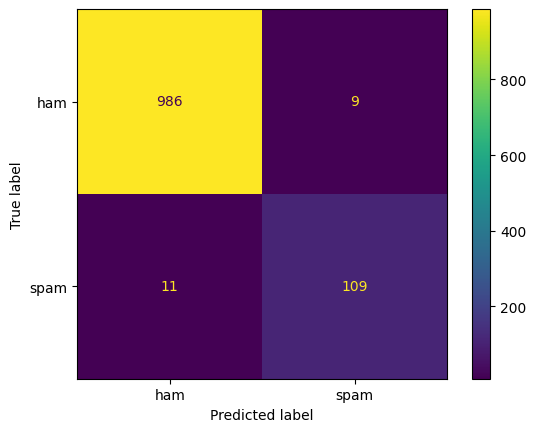

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["ham", "spam"])
disp.plot()
plt.show()

In [32]:
#%%writefile app.py
import streamlit as st

st.title("Hello from Streamlit 🚀")
st.write("Running inside Google Colab!")

2026-04-03 08:43:08.257 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 08:43:08.259 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 08:43:08.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 08:43:08.265 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 08:43:08.266 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 08:43:08.268 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [34]:
import os
#!pip install pyngrok
from pyngrok import ngrok

# Kill existing tunnels
ngrok.kill()

# Authenticate ngrok with your authtoken
# Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken.
# You can get it from https://dashboard.ngrok.com/get-started/your-authtoken
if os.getenv("NGROK_AUTHTOKEN") is None:
  # This is an example, replace with your actual authtoken if not set as an environment variable
  ngrok_auth_token = "YOUR_TOKEN"
  if ngrok_auth_token == "INCORRECT_TOKEN":
    print("Please replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken.")
  else:
    ngrok.set_auth_token(ngrok_auth_token)
else:
  ngrok.set_auth_token(os.getenv("NGROK_AUTHTOKEN"))

# Create tunnel
public_url = ngrok.connect(8501)
print(public_url)

# Run Streamlit
!streamlit run app.py &>/dev/null &

NgrokTunnel: "https://fortifyingly-subvertebral-naida.ngrok-free.dev" -> "http://localhost:8501"
